# Baseline Model (Decision Tree) notebook

## Libraries

In [81]:
# Import libraries
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

np.random.seed(24)

In [82]:
df = pd.read_csv("data/corona_tested_individuals_ver_006.csv", low_memory=False)
# df['test_date'] = pd.to_datetime(df['test_date'], dayfirst=True)

# df = pd.read_csv("data/corona_tested_individuals_ver_0083.english.zip", low_memory=False, compression="zip")

df = df[df["corona_result"] != "other"]

# Undersample negative corona_result cases to make the data more balanced
df_positive = df[df["corona_result"]=="positive"]
df_negative = df[df["corona_result"]=="negative"]

df = pd.concat([df_positive, df_negative.sample(n=len(df_positive), random_state=24)], axis=0) 

train, test = train_test_split(df, test_size=0.2, random_state=24)

In [83]:
df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
41,30/04/2020,1.0,0.0,0.0,0.0,0.0,positive,NaN,male,Contact with confirmed
43,30/04/2020,1.0,0.0,0.0,0.0,0.0,positive,NaN,female,Other
103,30/04/2020,0.0,0.0,0.0,0.0,0.0,positive,NaN,female,Contact with confirmed
120,30/04/2020,0.0,0.0,0.0,0.0,0.0,positive,NaN,male,Contact with confirmed
137,30/04/2020,1.0,1.0,0.0,0.0,0.0,positive,NaN,female,Other


**Question / Task 1**

Insert context about question / task 1 here.

In [84]:
# Add your code here


**Baseline model using only fever and cough as input features(decision tree)**

In [85]:
# Import necessary libraries for decision tree classifier and evaluation metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features (fever and cough) and target (corona_result)
features = ['fever', 'cough']
X_train = train[features]
y_train = train['corona_result']

X_test = test[features]
y_test = test['corona_result']

# Create and train the decision tree classifier
dt_model = DecisionTreeClassifier(random_state=24, max_depth=3)
dt_model.fit(X_train, y_train)

# Make predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, zero_division=0))

Training Accuracy: 0.7160
Test Accuracy: 0.7300

Confusion Matrix (Test Set):
[[2551  421]
 [1170 1750]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.69      0.86      0.76      2972
    positive       0.81      0.60      0.69      2920

    accuracy                           0.73      5892
   macro avg       0.75      0.73      0.72      5892
weighted avg       0.75      0.73      0.73      5892



In [86]:
dt_model.feature_importances_

array([0.70015857, 0.29984143])

**Roc curve**

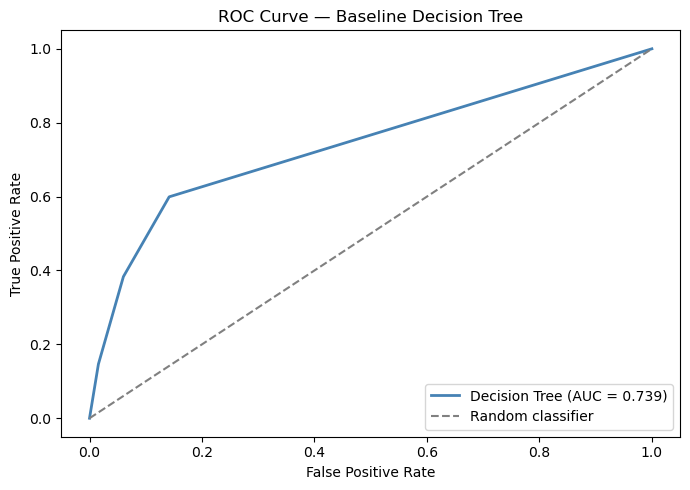

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_test_proba = dt_model.predict_proba(X_test)[:, list(dt_model.classes_).index('positive')]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba, pos_label='positive')
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Decision Tree (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Baseline model using all features as input (decision tree)**

In [88]:
# Import necessary libraries for decision tree classifier and evaluation metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features (all except test_date and corona_result) and target
feature_cols = [c for c in df.columns if c not in ('corona_result', 'test_date')]

X_train_all = pd.get_dummies(train[feature_cols])
y_train = train['corona_result']

X_test_all = pd.get_dummies(test[feature_cols])
# Align columns in case train/test dummies differ
X_train_all, X_test_all = X_train_all.align(X_test_all, join='left', axis=1, fill_value=0)

# Create and train the decision tree classifier
dt_model_all = DecisionTreeClassifier(random_state=24, max_depth=3)
dt_model_all.fit(X_train_all, y_train)

# Make predictions
y_train_pred_all = dt_model_all.predict(X_train_all)
y_test_pred_all = dt_model_all.predict(X_test_all)

# Evaluate the model
train_accuracy_all = accuracy_score(y_train, y_train_pred_all)
test_accuracy_all = accuracy_score(y_test, y_test_pred_all)

print(f"Training Accuracy: {train_accuracy_all:.4f}")
print(f"Test Accuracy: {test_accuracy_all:.4f}")
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred_all))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_all, zero_division=0))

Training Accuracy: 0.8291
Test Accuracy: 0.8323

Confusion Matrix (Test Set):
[[2757  215]
 [ 773 2147]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.78      0.93      0.85      2972
    positive       0.91      0.74      0.81      2920

    accuracy                           0.83      5892
   macro avg       0.84      0.83      0.83      5892
weighted avg       0.84      0.83      0.83      5892



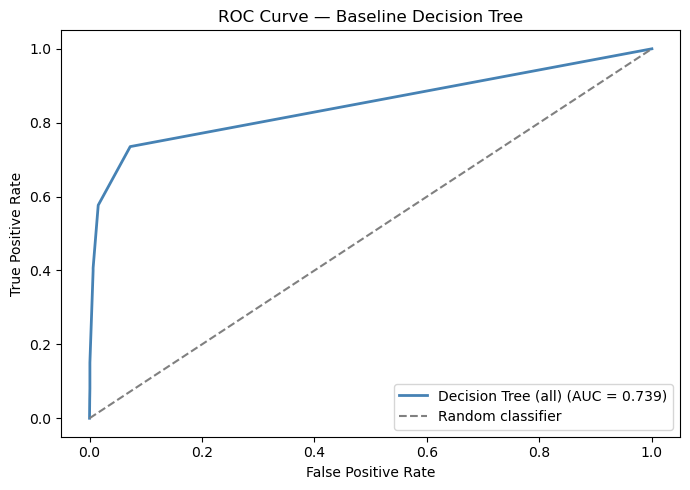

In [89]:
# Get predicted probabilities for the positive class
y_test_proba_all = dt_model_all.predict_proba(X_test_all)[:, list(dt_model_all.classes_).index('positive')]

# Compute ROC curve and AUC score
fpr_all, tpr_all, thresholds_all = roc_curve(y_test, y_test_proba_all, pos_label='positive')
auc_score_all = roc_auc_score(y_test, y_test_proba_all)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_all, tpr_all, color='steelblue', lw=2, label=f'Decision Tree (all) (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Dimensionality Reduction for Fun (t-SNE + UMAP)**

> Reduce features to 2D and inspect whether positive/negative classes form separate clusters.

UMAP is not installed. Run: pip install umap-learn


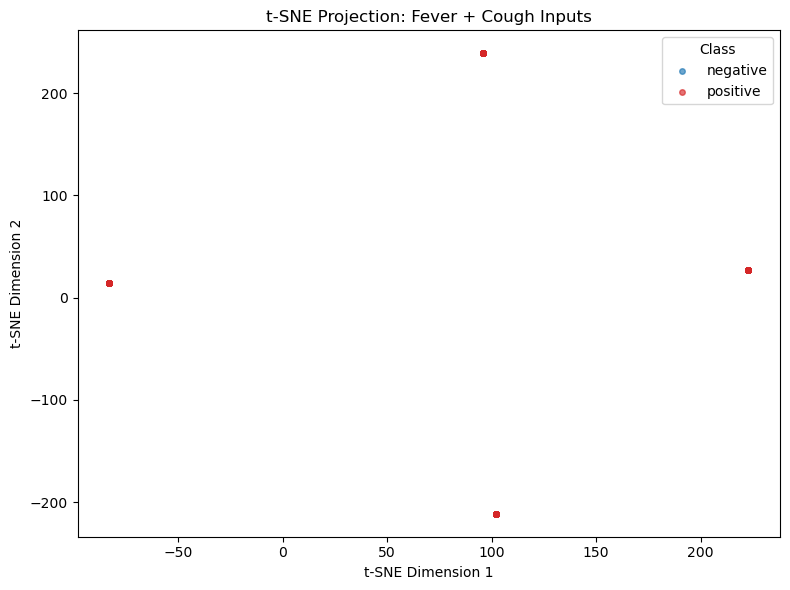

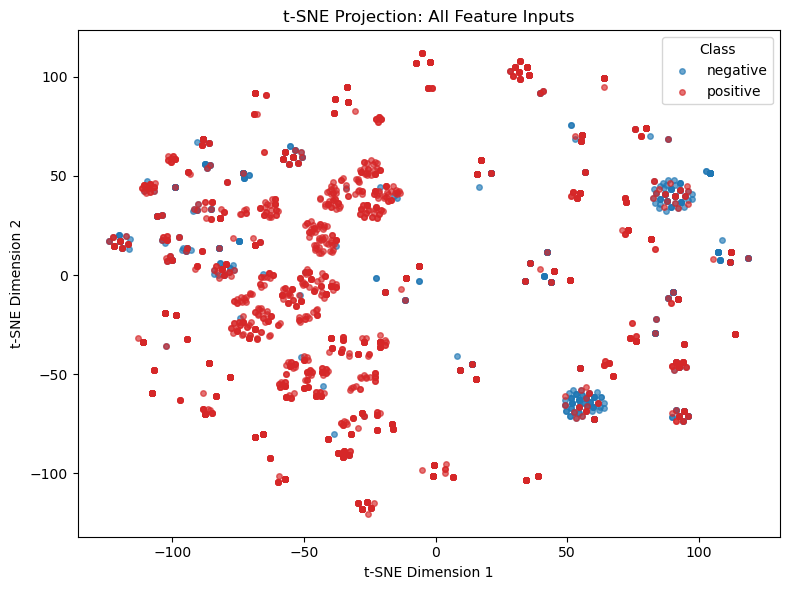

Skipping UMAP for UMAP Projection: Fever + Cough Inputs: umap-learn not installed.
Skipping UMAP for UMAP Projection: All Feature Inputs: umap-learn not installed.


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

try:
    from umap import UMAP
    umap_available = True
except ImportError:
    umap_available = False
    print("UMAP is not installed. Run: pip install umap-learn")

# Keep runtime manageable while preserving class proportions
if len(df) > 5000:
    _, vis_df = train_test_split(
        df,
        test_size=5000,
        stratify=df['corona_result'],
        random_state=24
    )
else:
    vis_df = df.copy()

y_vis = vis_df['corona_result']

def prepare_projection_inputs(X_raw):
    X_encoded = pd.get_dummies(X_raw)

    # t-SNE and UMAP do not accept NaN values, so impute missing entries first
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X_encoded)

    return StandardScaler(with_mean=False).fit_transform(X_imputed)

def plot_projection(X_2d, y_labels, title, x_label, y_label):
    vis_plot_df = pd.DataFrame({
        'dim1': X_2d[:, 0],
        'dim2': X_2d[:, 1],
        'corona_result': y_labels.to_numpy()
    })

    plt.figure(figsize=(8, 6))
    for label, color in [('negative', '#1f77b4'), ('positive', '#d62728')]:
        subset = vis_plot_df[vis_plot_df['corona_result'] == label]
        plt.scatter(
            subset['dim1'],
            subset['dim2'],
            s=16,
            alpha=0.65,
            c=color,
            label=label
        )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

def plot_tsne_projection(X_raw, y_labels, title):
    X_scaled = prepare_projection_inputs(X_raw)
    n_samples = len(X_scaled)
    if n_samples < 3:
        print(f"Skipping t-SNE for {title}: not enough samples ({n_samples}).")
        return

    perplexity = min(30, max(2, n_samples // 10))
    if perplexity >= n_samples:
        perplexity = n_samples - 1

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate='auto',
        init='pca',
        random_state=24
    )
    X_tsne = tsne.fit_transform(X_scaled)
    plot_projection(X_tsne, y_labels, title, 't-SNE Dimension 1', 't-SNE Dimension 2')

def plot_umap_projection(X_raw, y_labels, title):
    if not umap_available:
        print(f"Skipping UMAP for {title}: umap-learn not installed.")
        return

    X_scaled = prepare_projection_inputs(X_raw)
    umap_model = UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric='euclidean',
        random_state=24
    )
    X_umap = umap_model.fit_transform(X_scaled)
    plot_projection(X_umap, y_labels, title, 'UMAP Dimension 1', 'UMAP Dimension 2')

# t-SNE plots for both input sets
# plot_tsne_projection(vis_df[features], y_vis, 't-SNE Projection: Fever + Cough Inputs')
plot_tsne_projection(vis_df[feature_cols], y_vis, 't-SNE Projection: All Feature Inputs')

# UMAP plots for both input sets -- UMAP NOT INSTALLED
# plot_umap_projection(vis_df[features], y_vis, 'UMAP Projection: Fever + Cough Inputs')
# plot_umap_projection(vis_df[feature_cols], y_vis, 'UMAP Projection: All Feature Inputs')

In [91]:
# Save the models to disk
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

with open(models_dir / 'decision_tree_fever_cough.pkl', 'wb') as model_file:
    pickle.dump(dt_model, model_file)

with open(models_dir / 'decision_tree_all_features.pkl', 'wb') as model_all_file:
    pickle.dump(dt_model_all, model_all_file)

print('Saved baseline model to models/decision_tree_fever_cough.pkl')
print('Saved all-features model to models/decision_tree_all_features.pkl')

Saved baseline model to models/decision_tree_fever_cough.pkl
Saved all-features model to models/decision_tree_all_features.pkl
